In [49]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl
import cmocean

In [20]:
os.chdir('.../')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')
dx = data.variables['e1t']
dy = data.variables['e2t']
e3t = data.variables['e3t_0']
lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 
bat = data.variables['hdept']
bat = bat[0]

In [24]:
os.chdir('.../mld')

mld_vs = np.load('ANHA4-EJM010-S_Dataset_MLD_20071_20173_x150-300_y300-450.npz')
mld_vs = mld_vs['mld_ts']

mld_vd = np.load('ANHA4-EJM012-S_Dataset_MLD_20071_20173_x150-300_y300-450.npz')
mld_vd = mld_vd['mld_ts']


In [25]:
average_vs_mld = np.nanmean(mld_vs, axis = 0)
average_vs_mld = average_vs_mld[:, 0:100]

average_vd_mld = np.nanmean(mld_vd, axis = 0)
average_vd_mld = average_vd_mld[:, 0:100]

dif_mld = average_vd_mld - average_vs_mld

/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_10606/3858439491.py:1: RuntimeWarning: Mean of empty slice
  average_vs_mld = np.nanmean(mld_vs, axis = 0)
/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_10606/3858439491.py:4: RuntimeWarning: Mean of empty slice
  average_vd_mld = np.nanmean(mld_vd, axis = 0)


In [21]:
xlim1 = 150
xlim2 = 250
ylim1 = 300
ylim2 = 450

lon = lon[ylim1:ylim2, xlim1:xlim2]
lat = lat[ylim1:ylim2, xlim1:xlim2]
bat = bat[ylim1:ylim2, xlim1:xlim2]

In [34]:
path = '.../Figure2&12_ConvectiverResistance/'

years = range(2007, 2018)

vs_cr_all = []

for year in years:
    filename = f'ANHA4-EJM010-S_{year}_CR_Winter_LS.npz'
    filepath = os.path.join(path, filename)
    data = np.load(filepath)['ConvR']
    vs_cr_all.append(data)

vs_cr_all = np.concatenate(vs_cr_all, axis=0)

vd_cr_all = []

for year in years:
    filename = f'ANHA4-EJM012-S_{year}_CR_Winter_LS.npz'
    filepath = os.path.join(path, filename)
    data = np.load(filepath)['ConvR']
    vd_cr_all.append(data)

vd_cr_all = np.concatenate(vd_cr_all, axis=0)

dif_cr = average_vd_cr - average_vs_cr

print('\nDifference:')
print('dif_cr:', dif_cr.shape)


Difference:
dif_cr: (150, 100)


In [35]:
average_vs_cr = np.nanmean(vs_cr_all, axis=0)
average_vs_cr = average_vs_cr[:, 0:100]

average_vd_cr = np.nanmean(vd_cr_all, axis = 0)
average_vd_cr = average_vd_cr[:, 0:100]

dif_cr = average_vd_cr - average_vs_cr

/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_10606/702767081.py:1: RuntimeWarning: Mean of empty slice
  average_vs_cr = np.nanmean(vs_cr_all, axis=0)
/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_10606/702767081.py:4: RuntimeWarning: Mean of empty slice
  average_vd_cr = np.nanmean(vd_cr_all, axis = 0)


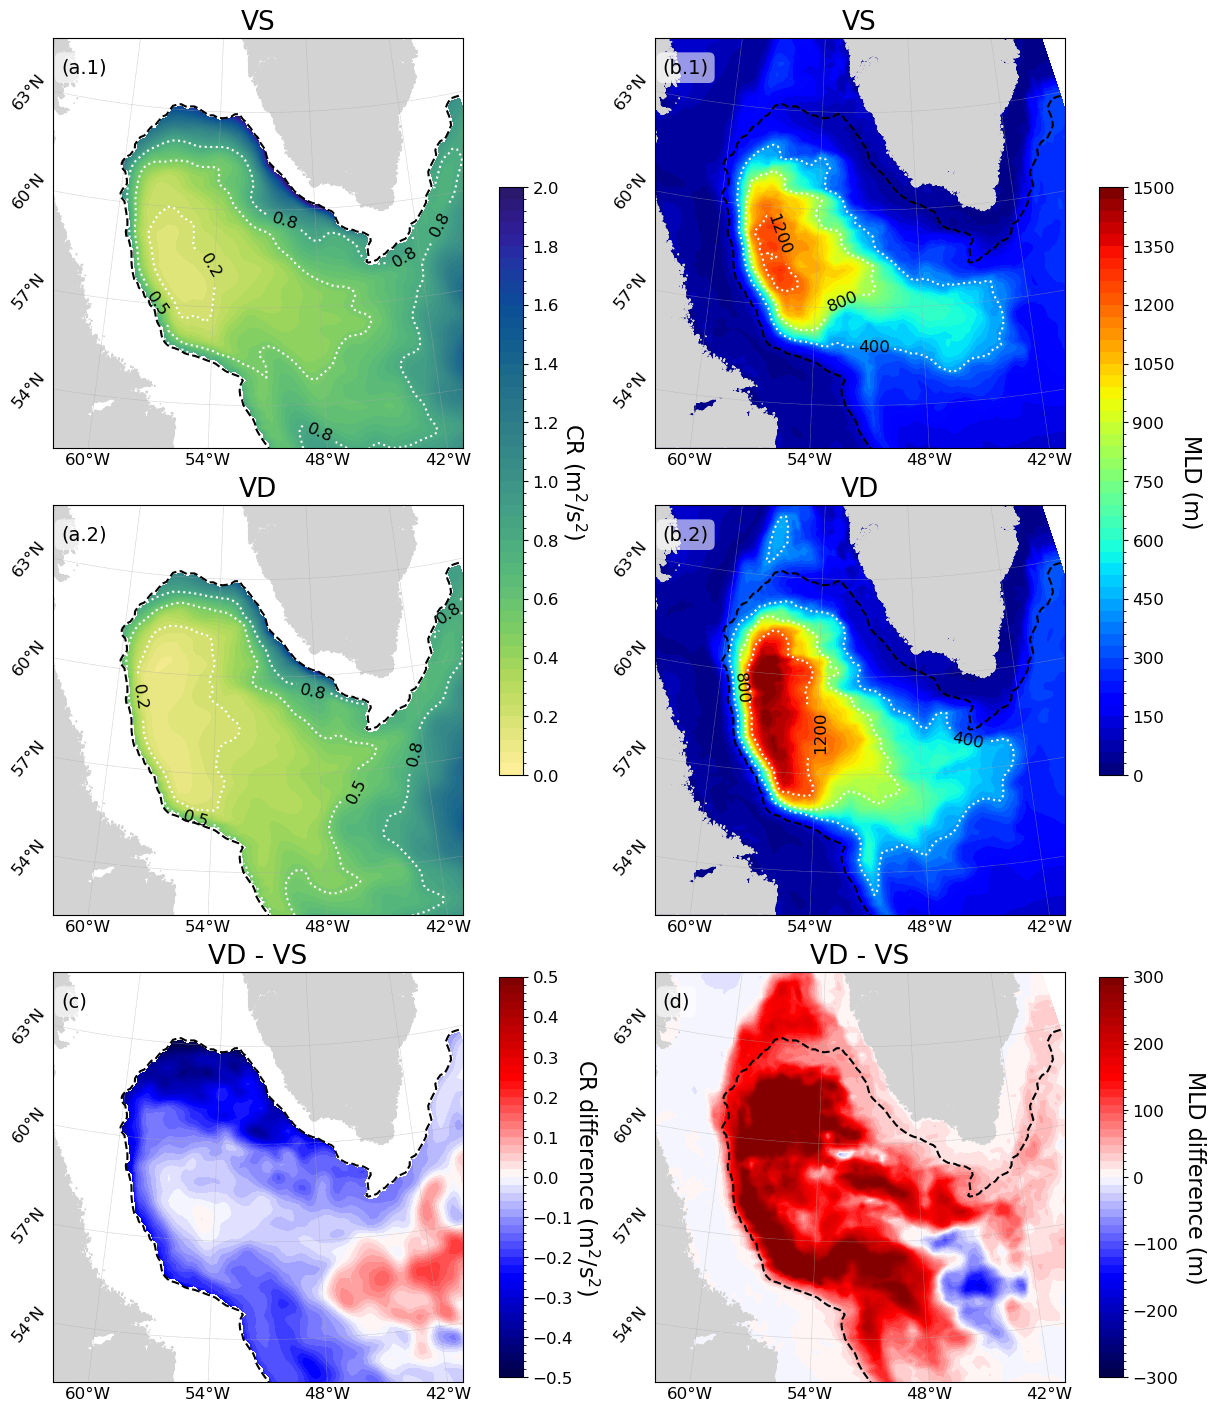

In [60]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,14), constrained_layout=True)

vmins_mld = [0, 0, -300]
vmaxs_mld = [1500, 1500, 300]
vmins_cr = [0, 0, -0.5]
vmaxs_cr = [2, 2, 0.5]

lvs = 50

lv_data_mld = (vmaxs_mld[0] - vmins_mld[0])/lvs
levels_data_mld = list(np.arange(vmins_mld[0], vmaxs_mld[0]+lv_data_mld, lv_data_mld))
lv_dif_mld = (vmaxs_mld[2] - vmins_mld[2])/lvs
levels_dif_mld = list(np.arange(vmins_mld[2], vmaxs_mld[2]+lv_dif_mld, lv_dif_mld))
levels_mld = [levels_data_mld, levels_data_mld, levels_dif_mld]

lv_data_cr = (vmaxs_cr[0] - vmins_cr[0])/lvs
levels_data_cr = list(np.arange(vmins_cr[0], vmaxs_cr[0]+lv_data_cr, lv_data_cr))
lv_dif_cr = (vmaxs_cr[2] - vmins_cr[2])/lvs
levels_dif_cr = list(np.arange(vmins_cr[2], vmaxs_cr[2]+lv_dif_cr, lv_dif_cr))
levels_cr = [levels_data_cr, levels_data_cr, levels_dif_cr]

cmaps_mld = [plt.get_cmap('jet'), plt.get_cmap('jet'), plt.get_cmap('seismic')]
cmaps_cr = [cmocean.cm.haline.reversed(), cmocean.cm.haline.reversed(), plt.get_cmap('seismic')]

titles = ['VS', 'VD', 'VD - VS']

average_vd_mld = np.clip(average_vd_mld, 0, 1500)
average_vs_mld = np.clip(average_vs_mld, 0, 1500)
dif_mld = np.clip(dif_mld, -300, 300)

average_vd_cr = np.clip(average_vd_cr, 0, 2)
average_vs_cr = np.clip(average_vs_cr, 0, 2)
dif_cr = np.clip(dif_cr, -0.5, 0.5)

data_list_mld = [average_vs_mld, average_vd_mld, dif_mld]
data_list_cr = [average_vs_cr, average_vd_cr, dif_cr]

for i in range(3):
    ax = axes[i, 0]
    data = data_list_cr[i]
    ax.set_title(titles[i], fontsize=19)
    m = Basemap(projection='aea', resolution='f', width=14E5, height=14E5, lat_0=59, lon_0=-51.5, ax=ax)
    m.contourf(lon, lat, data, latlon=True, levels=levels_cr[i], vmin=vmins_cr[i], vmax=vmaxs_cr[i], cmap=cmaps_cr[i])
    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0,360,6), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=12)
    m.drawparallels(np.arange(-90,90,3), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=12, rotation=50)
    bath_contour = m.contour(lon, lat, bat, latlon=True, levels=[2000], colors='black', linewidths=1.5, linestyles='dashed')
    ct = m.contour(lon, lat, data, latlon=True, levels=[0.2, 0.5, 0.8], colors='white', linewidths=1.5, linestyles='dotted')
    plt.clabel(ct, colors='black', fontsize=12)

    ax = axes[i, 1]
    data = data_list_mld[i]
    ax.set_title(titles[i], fontsize=19)
    m = Basemap(projection='aea', resolution='f', width=14E5, height=14E5, lat_0=59, lon_0=-51.5, ax=ax)
    m.contourf(lon, lat, data, latlon=True, levels=levels_mld[i], vmin=vmins_mld[i], vmax=vmaxs_mld[i], cmap=cmaps_mld[i])
    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0,360,6), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=12)
    m.drawparallels(np.arange(-90,90,3), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=12, rotation=50)
    bath_contour = m.contour(lon, lat, bat, latlon=True, levels=[2000], colors='black', linewidths=1.5, linestyles='dashed')
    ct = m.contour(lon, lat, data, latlon=True, levels=[400, 800, 1200], colors='white', linewidths=1.5, linestyles='dotted')
    plt.clabel(ct, colors='black', fontsize=12)

import matplotlib as mpl
from matplotlib.colors import BoundaryNorm

cax1 = fig.add_axes([0.45, 0.45, 0.020, 0.42])
lv = np.linspace(vmins_cr[0], vmaxs_cr[0], len(levels_cr[0]))
norm = BoundaryNorm(lv, ncolors=cmaps_cr[0].N, clip=True)
cb1 = mpl.colorbar.ColorbarBase(cax1, cmap=cmaps_cr[0], norm=norm, orientation='vertical')
cb1.ax.set_ylabel('CR (m$^2$/s$^2$)', rotation=270, labelpad=21, fontsize=16)
cb1.set_ticks(np.arange(0, 2.1, 0.2))
cb1.ax.tick_params(labelsize=12)

cax2 = fig.add_axes([0.45, 0.02, 0.020, 0.286])
lv = np.linspace(vmins_cr[2], vmaxs_cr[2], len(levels_cr[2]))
norm = BoundaryNorm(lv, ncolors=cmaps_cr[2].N, clip=True)
cb2 = mpl.colorbar.ColorbarBase(cax2, cmap=cmaps_cr[2], norm=norm, orientation='vertical')
cb2.ax.set_ylabel('CR difference (m$^2$/s$^2$)', rotation=270, labelpad=20, fontsize=16)
cb2.set_ticks(np.arange(-0.5, 0.6, 0.1))
cb2.ax.tick_params(labelsize=12)

cax3 = fig.add_axes([0.95, 0.45, 0.020, 0.42])
lv = np.linspace(vmins_mld[0], vmaxs_mld[0], len(levels_mld[0]))
norm = BoundaryNorm(lv, ncolors=cmaps_mld[0].N, clip=True)
cb3 = mpl.colorbar.ColorbarBase(cax3, cmap=cmaps_mld[0], norm=norm, orientation='vertical')
cb3.ax.set_ylabel('MLD (m)', rotation=270, labelpad=20, fontsize=16)
cb3.ax.ticklabel_format(style='sci', scilimits=(-1,4), axis='both')
cb3.set_ticks(np.arange(0, 1600, 150))
cb3.ax.tick_params(labelsize=12)

cax4 = fig.add_axes([0.95, 0.02, 0.020, 0.286])
lv = np.linspace(vmins_mld[2], vmaxs_mld[2], len(levels_mld[2]))
norm = BoundaryNorm(lv, ncolors=cmaps_mld[2].N, clip=True)
cb4 = mpl.colorbar.ColorbarBase(cax4, cmap=cmaps_mld[2], norm=norm, orientation='vertical')
cb4.ax.set_ylabel('MLD difference (m)', rotation=270, labelpad=20, fontsize=16)
cb4.set_ticks(np.arange(-300, 400, 100))
cb4.ax.tick_params(labelsize=12)

labels_cr = ['a.1', 'a.2', 'c']
labels_mld = ['b.1', 'b.2', 'd']

for i, ax in enumerate(axes[:, 0]):
    color = 'black'
    ax.text(0.02, 0.95, f'({labels_cr[i]})', transform=ax.transAxes, fontsize=14, va='top', ha='left', color=color, 
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))

for i, ax in enumerate(axes[:, 1]):
    color = 'black'
    ax.text(0.02, 0.95, f'({labels_mld[i]})', transform=ax.transAxes, fontsize=14, va='top', ha='left', color=color, 
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))

figure_title = 'LabradorSea_CR_MLD'
os.chdir('...Figure2&12_ConvectiverResistance/')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()